## 🚗 Used Car Engine Type Prediction

Given *data about used cars*, let's try to predict the **engine type** of a given car.

We will use a TensorFlow ANN to make our predictions.

Data source: https://www.kaggle.com/datasets/lepchenkov/usedcarscatalog

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('archive/cars.csv')
data

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,price_usd,is_exchangeable,location_region,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,universal,False,owned,all,10900.00,False,Минская обл.,9,13,False,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,universal,False,owned,all,5000.00,True,Минская обл.,12,54,False,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,suv,False,owned,all,2800.00,True,Минская обл.,4,72,False,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,sedan,False,owned,all,9999.00,True,Минская обл.,9,42,True,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,universal,False,owned,all,2134.11,True,Гомельская обл.,14,7,False,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,sedan,False,owned,front,2750.00,True,Минская обл.,5,85,False,True,False,False,True,True,False,False,True,True,301
38527,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,hatchback,False,owned,front,4800.00,True,Брестская обл.,4,20,False,True,False,False,True,True,False,False,True,True,317
38528,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,sedan,False,owned,front,4300.00,False,Минская обл.,3,63,False,True,False,False,True,True,False,False,True,True,369
38529,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,minivan,False,owned,front,4000.00,True,Брестская обл.,7,156,False,True,False,False,False,False,False,False,False,True,490


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  str    
 1   model_name         38531 non-null  str    
 2   transmission       38531 non-null  str    
 3   color              38531 non-null  str    
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  str    
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  str    
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  str    
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  str    
 13  drivetrain         38531 non-null  str    
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    38531 non-null

In [4]:
print("Total Missing Values:", data.isna().sum().sum())

Total Missing Values: 10


#### Filling missing values

In [5]:
print("Columns with missing values:", data.columns[data.isna().sum() > 0].values[0])

Columns with missing values: engine_capacity


In [6]:
data['engine_capacity'].dtype

dtype('float64')

In [7]:
data['engine_capacity'] = data['engine_capacity'].fillna(data['engine_capacity'].mean())

In [8]:
print("Total Missing Values:", data.isna().sum().sum())

Total Missing Values: 0


#### Encoding Features

In [9]:
data

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,price_usd,is_exchangeable,location_region,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,universal,False,owned,all,10900.00,False,Минская обл.,9,13,False,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,universal,False,owned,all,5000.00,True,Минская обл.,12,54,False,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,suv,False,owned,all,2800.00,True,Минская обл.,4,72,False,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,sedan,False,owned,all,9999.00,True,Минская обл.,9,42,True,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,universal,False,owned,all,2134.11,True,Гомельская обл.,14,7,False,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,sedan,False,owned,front,2750.00,True,Минская обл.,5,85,False,True,False,False,True,True,False,False,True,True,301
38527,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,hatchback,False,owned,front,4800.00,True,Брестская обл.,4,20,False,True,False,False,True,True,False,False,True,True,317
38528,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,sedan,False,owned,front,4300.00,False,Минская обл.,3,63,False,True,False,False,True,True,False,False,True,True,369
38529,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,minivan,False,owned,front,4000.00,True,Брестская обл.,7,156,False,True,False,False,False,False,False,False,False,True,490


Let's just make all the boolean columns into integer columns.

In [10]:
for column in data.columns:
    if data.dtypes[column] == 'bool':
        data[column] = data[column].astype(int)

In [11]:
data

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,price_usd,is_exchangeable,location_region,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,0,gasoline,2.5,universal,0,owned,all,10900.00,0,Минская обл.,9,13,0,1,1,1,0,1,0,1,1,1,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,0,gasoline,3.0,universal,0,owned,all,5000.00,1,Минская обл.,12,54,0,1,0,0,1,1,0,0,0,1,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,0,gasoline,2.5,suv,0,owned,all,2800.00,1,Минская обл.,4,72,0,1,0,0,0,0,0,0,1,1,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,0,gasoline,3.0,sedan,0,owned,all,9999.00,1,Минская обл.,9,42,1,0,0,0,0,0,0,0,0,0,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,0,gasoline,2.5,universal,0,owned,all,2134.11,1,Гомельская обл.,14,7,0,1,0,1,1,0,0,0,0,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,automatic,silver,290000,2000,gasoline,0,gasoline,3.5,sedan,0,owned,front,2750.00,1,Минская обл.,5,85,0,1,0,0,1,1,0,0,1,1,301
38527,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,0,diesel,2.2,hatchback,0,owned,front,4800.00,1,Брестская обл.,4,20,0,1,0,0,1,1,0,0,1,1,317
38528,Chrysler,300,automatic,blue,777957,2000,gasoline,0,gasoline,3.5,sedan,0,owned,front,4300.00,0,Минская обл.,3,63,0,1,0,0,1,1,0,0,1,1,369
38529,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,0,gasoline,2.0,minivan,0,owned,front,4000.00,1,Брестская обл.,7,156,0,1,0,0,0,0,0,0,0,1,490


In [12]:
{column: len(data[column].unique()) for column in data.columns if data.dtypes[column] == 'str'}

{'manufacturer_name': 55,
 'model_name': 1118,
 'transmission': 2,
 'color': 12,
 'engine_fuel': 6,
 'engine_type': 3,
 'body_type': 12,
 'state': 3,
 'drivetrain': 3,
 'location_region': 6}

*model_name* has too many unique features (high cardinality), so let's drop that column.

In [13]:
# Drop high cardinality column
data = data.drop('model_name', axis=1)

*transmission* has only two unique values, so we can encode it as a binary feature.

In [14]:
data['transmission'].unique()

<StringArray>
['automatic', 'mechanical']
Length: 2, dtype: str

In [15]:
transmission_mapping = {'automatic': 0, 'mechanical': 1}

data['transmission'] = data['transmission'].replace(transmission_mapping).astype(int)

All the remaining features can be one-hot encoded.

We will not encode *engine_type*, as that is our label column.

In [16]:
def onehot_encode(df, columns, prefixes):
    df = df.copy()
    for column, prefix in zip(columns, prefixes):
        dummies = pd.get_dummies(df[column], prefix=prefix, dtype=int)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

In [17]:
nominal_features = [
    'manufacturer_name',
 'color',
 'engine_fuel',
 'body_type',
 'state',
 'drivetrain',
 'location_region'
]

nominal_prefixes = [
    'MA',
    'CO',
    'EF',
    'BO',
    'ST',
    'DR',
    'LO'
]

data = onehot_encode(
    data,
    columns=nominal_features,
    prefixes=nominal_prefixes
)

In [18]:
data

,transmission,odometer_value,year_produced,engine_has_gas,engine_type,engine_capacity,has_warranty,price_usd,is_exchangeable,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,MA_Acura,MA_Alfa Romeo,MA_Audi,MA_BMW,MA_Buick,MA_Cadillac,MA_Chery,MA_Chevrolet,MA_Chrysler,MA_Citroen,MA_Dacia,MA_Daewoo,MA_Dodge,MA_Fiat,MA_Ford,MA_Geely,MA_Great Wall,MA_Honda,MA_Hyundai,MA_Infiniti,MA_Iveco,MA_Jaguar,MA_Jeep,MA_Kia,MA_LADA,MA_Lancia,MA_Land Rover,MA_Lexus,MA_Lifan,MA_Lincoln,MA_Mazda,MA_Mercedes-Benz,MA_Mini,MA_Mitsubishi,MA_Nissan,MA_Opel,MA_Peugeot,MA_Pontiac,MA_Porsche,MA_Renault,MA_Rover,MA_Saab,MA_Seat,MA_Skoda,MA_SsangYong,MA_Subaru,MA_Suzuki,MA_Toyota,MA_Volkswagen,MA_Volvo,MA_ВАЗ,MA_ГАЗ,MA_ЗАЗ,MA_Москвич,MA_УАЗ,CO_black,CO_blue,CO_brown,CO_green,CO_grey,CO_orange,CO_other,CO_red,CO_silver,CO_violet,CO_white,CO_yellow,EF_diesel,EF_electric,EF_gas,EF_gasoline,EF_hybrid-diesel,EF_hybrid-petrol,BO_cabriolet,BO_coupe,BO_hatchback,BO_liftback,BO_limousine,BO_minibus,BO_minivan,BO_pickup,BO_sedan,BO_suv,BO_universal,BO_van,ST_emergency,ST_new,ST_owned,DR_all,DR_front,DR_rear,LO_Брестская обл.,LO_Витебская обл.,LO_Гомельская обл.,LO_Гродненская обл.,LO_Минская обл.,LO_Могилевская обл.
0,0,190000,2010,0,gasoline,2.5,0,10900.00,0,9,13,0,1,1,1,0,1,0,1,1,1,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0
1,0,290000,2002,0,gasoline,3.0,0,5000.00,1,12,54,0,1,0,0,1,1,0,0,0,1,83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0
2,0,402000,2001,0,gasoline,2.5,0,2800.00,1,4,72,0,1,0,0,0,0,0,0,1,1,151,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0
3,1,10000,1999,0,gasoline,3.0,0,9999.00,1,9,42,1,0,0,0,0,0,0,0,0,0,86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0
4,0,280000,2001,0,gasoline,2.5,0,2134.11,1,14,7,0,1,0,1,1,0,0,0,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,0,290000,2000,0,gasoline,3.5,0,2750.00,1,5,85,0,1,0,0,1,1,0,0,1,1,301,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
38527,1,321000,2004,0,diesel,2.2,0,4800.00,1,4,20,0,1,0,0,1,1,0,0,1,1,317,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0
38528,0,777957,2000,0,gasoline,3.5,0,4300.00,0,3,63,0,1,0,0,1,1,0,0,1,1,369,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
38529,1,20000,2001,0,gasoline,2.0,0,4000.00,1,7,156,0,1,0,0,0,0,0,0,0,1,490,0,0,0,0,0,0,0,0,1,0

In [19]:
print("Remaining non-numeric columns:", len(data.columns[data.dtypes == 'str']))

Remaining non-numeric columns: 1


#### Encoding Labels

In [20]:
data['engine_type'].unique()

<StringArray>
['gasoline', 'diesel', 'electric']
Length: 3, dtype: str

In [21]:
label_mapping = {
    'gasoline': 0,
    'diesel': 1,
    'electric': 2
}

data['engine_type'] = data['engine_type'].replace(label_mapping)

In [22]:
print("Remaining non-numeric columns:", len(data.columns[data.dtypes == 'str']))

Remaining non-numeric columns: 0


#### Visualizing Correlations

In [23]:
data

,transmission,odometer_value,year_produced,engine_has_gas,engine_type,engine_capacity,has_warranty,price_usd,is_exchangeable,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,MA_Acura,MA_Alfa Romeo,MA_Audi,MA_BMW,MA_Buick,MA_Cadillac,MA_Chery,MA_Chevrolet,MA_Chrysler,MA_Citroen,MA_Dacia,MA_Daewoo,MA_Dodge,MA_Fiat,MA_Ford,MA_Geely,MA_Great Wall,MA_Honda,MA_Hyundai,MA_Infiniti,MA_Iveco,MA_Jaguar,MA_Jeep,MA_Kia,MA_LADA,MA_Lancia,MA_Land Rover,MA_Lexus,MA_Lifan,MA_Lincoln,MA_Mazda,MA_Mercedes-Benz,MA_Mini,MA_Mitsubishi,MA_Nissan,MA_Opel,MA_Peugeot,MA_Pontiac,MA_Porsche,MA_Renault,MA_Rover,MA_Saab,MA_Seat,MA_Skoda,MA_SsangYong,MA_Subaru,MA_Suzuki,MA_Toyota,MA_Volkswagen,MA_Volvo,MA_ВАЗ,MA_ГАЗ,MA_ЗАЗ,MA_Москвич,MA_УАЗ,CO_black,CO_blue,CO_brown,CO_green,CO_grey,CO_orange,CO_other,CO_red,CO_silver,CO_violet,CO_white,CO_yellow,EF_diesel,EF_electric,EF_gas,EF_gasoline,EF_hybrid-diesel,EF_hybrid-petrol,BO_cabriolet,BO_coupe,BO_hatchback,BO_liftback,BO_limousine,BO_minibus,BO_minivan,BO_pickup,BO_sedan,BO_suv,BO_universal,BO_van,ST_emergency,ST_new,ST_owned,DR_all,DR_front,DR_rear,LO_Брестская обл.,LO_Витебская обл.,LO_Гомельская обл.,LO_Гродненская обл.,LO_Минская обл.,LO_Могилевская обл.
0,0,190000,2010,0,0,2.5,0,10900.00,0,9,13,0,1,1,1,0,1,0,1,1,1,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0
1,0,290000,2002,0,0,3.0,0,5000.00,1,12,54,0,1,0,0,1,1,0,0,0,1,83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0
2,0,402000,2001,0,0,2.5,0,2800.00,1,4,72,0,1,0,0,0,0,0,0,1,1,151,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0
3,1,10000,1999,0,0,3.0,0,9999.00,1,9,42,1,0,0,0,0,0,0,0,0,0,86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0
4,0,280000,2001,0,0,2.5,0,2134.11,1,14,7,0,1,0,1,1,0,0,0,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,0,290000,2000,0,0,3.5,0,2750.00,1,5,85,0,1,0,0,1,1,0,0,1,1,301,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
38527,1,321000,2004,0,1,2.2,0,4800.00,1,4,20,0,1,0,0,1,1,0,0,1,1,317,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0
38528,0,777957,2000,0,0,3.5,0,4300.00,0,3,63,0,1,0,0,1,1,0,0,1,1,369,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
38529,1,20000,2001,0,0,2.0,0,4000.00,1,7,156,0,1,0,0,0,0,0,0,0,1,490,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

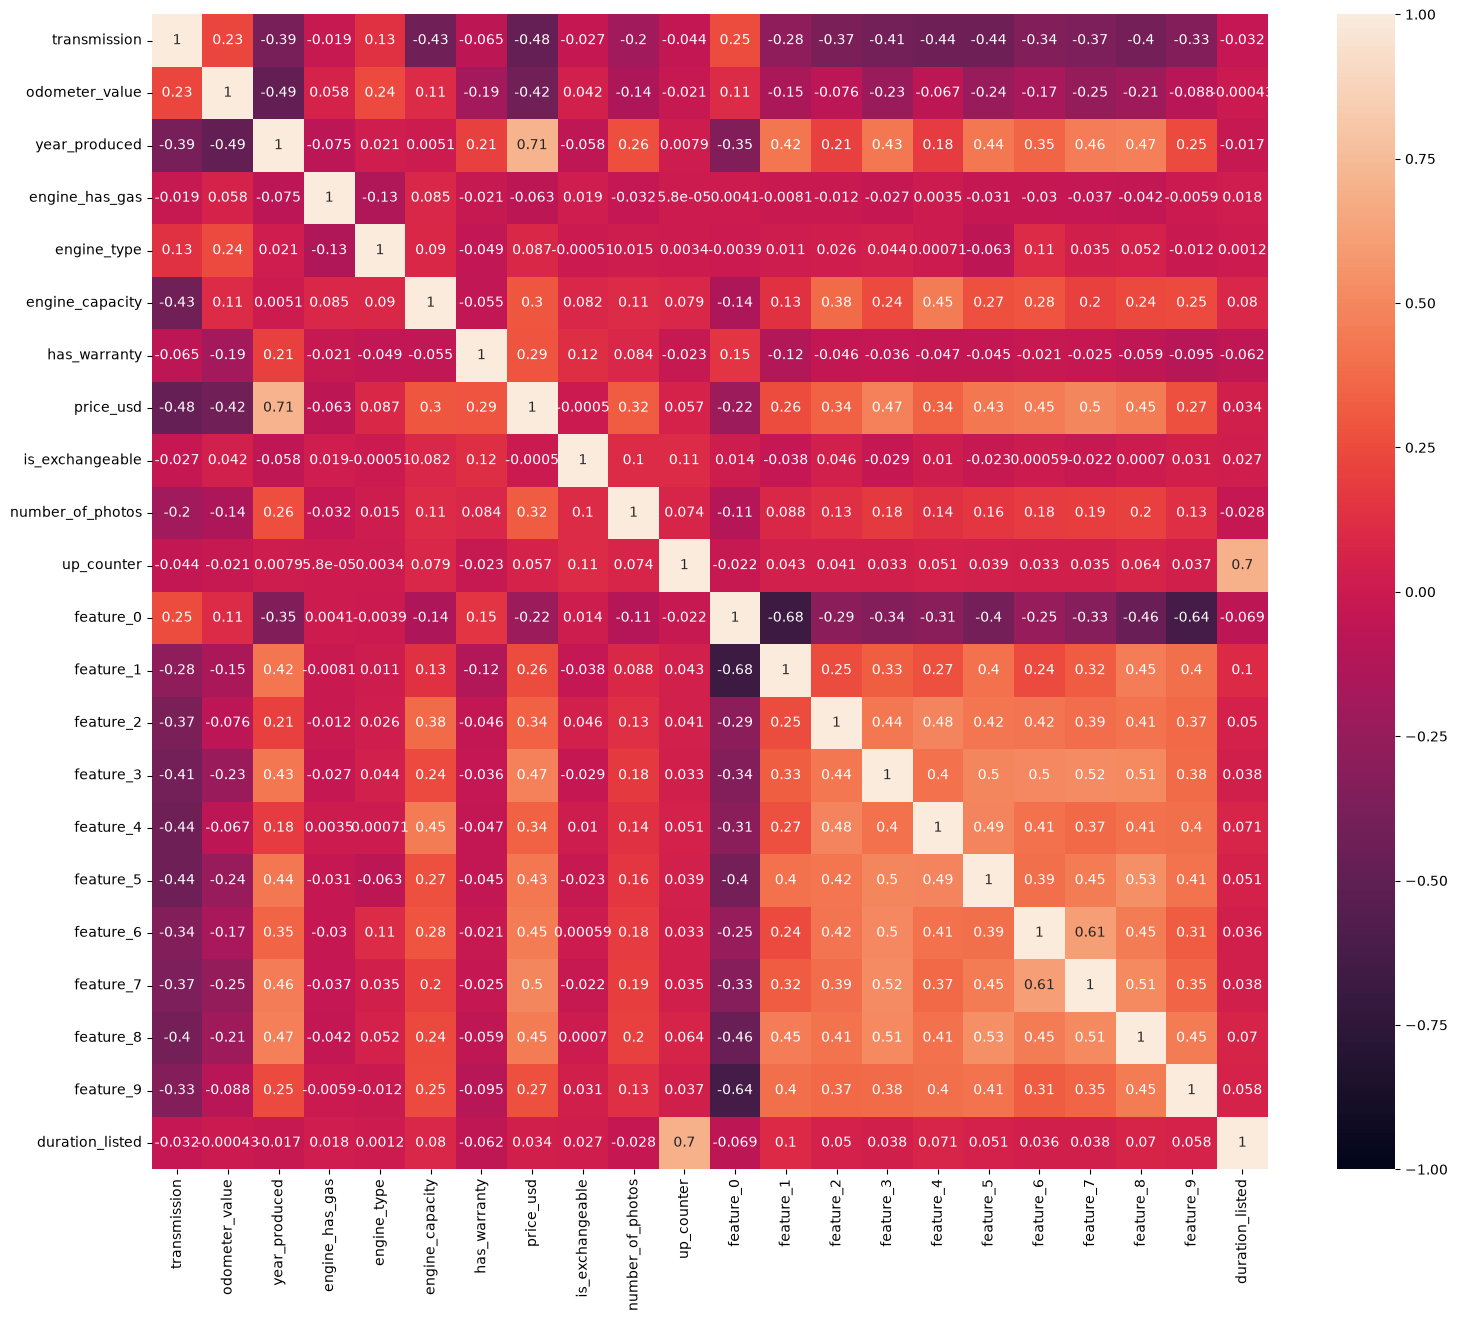

In [26]:
corr = data.loc[:, 'transmission':'duration_listed'].corr()

plt.figure(figsize=(18,15))
sns.heatmap(corr, annot=True, vmin=-1.0, cmap='rocket')
plt.show()

#### Splitting/Scaling

In [27]:
y = data['engine_type'].copy()
X = data.drop('engine_type', axis=1).copy()

In [28]:
scaler = StandardScaler()

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [38]:
y = y.astype(int)

In [29]:
X

,transmission,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,price_usd,is_exchangeable,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,MA_Acura,MA_Alfa Romeo,MA_Audi,MA_BMW,MA_Buick,MA_Cadillac,MA_Chery,MA_Chevrolet,MA_Chrysler,MA_Citroen,MA_Dacia,MA_Daewoo,MA_Dodge,MA_Fiat,MA_Ford,MA_Geely,MA_Great Wall,MA_Honda,MA_Hyundai,MA_Infiniti,MA_Iveco,MA_Jaguar,MA_Jeep,MA_Kia,MA_LADA,MA_Lancia,MA_Land Rover,MA_Lexus,MA_Lifan,MA_Lincoln,MA_Mazda,MA_Mercedes-Benz,MA_Mini,MA_Mitsubishi,MA_Nissan,MA_Opel,MA_Peugeot,MA_Pontiac,MA_Porsche,MA_Renault,MA_Rover,MA_Saab,MA_Seat,MA_Skoda,MA_SsangYong,MA_Subaru,MA_Suzuki,MA_Toyota,MA_Volkswagen,MA_Volvo,MA_ВАЗ,MA_ГАЗ,MA_ЗАЗ,MA_Москвич,MA_УАЗ,CO_black,CO_blue,CO_brown,CO_green,CO_grey,CO_orange,CO_other,CO_red,CO_silver,CO_violet,CO_white,CO_yellow,EF_diesel,EF_electric,EF_gas,EF_gasoline,EF_hybrid-diesel,EF_hybrid-petrol,BO_cabriolet,BO_coupe,BO_hatchback,BO_liftback,BO_limousine,BO_minibus,BO_minivan,BO_pickup,BO_sedan,BO_suv,BO_universal,BO_van,ST_emergency,ST_new,ST_owned,DR_all,DR_front,DR_rear,LO_Брестская обл.,LO_Витебская обл.,LO_Гомельская обл.,LO_Гродненская обл.,LO_Минская обл.,LO_Могилевская обл.
0,-1.409738,-0.432604,0.874857,-0.190329,0.662868,-0.108583,0.662723,-0.737996,-0.106523,-0.076377,-0.544288,0.804304,1.862225,1.620421,-0.564213,1.344761,-0.454139,1.670831,1.186481,0.852005,-0.572366,-0.041423,-0.073494,-0.261602,-0.269554,-0.034947,-0.033425,-0.038827,-0.106982,-0.103707,-0.205552,-0.039161,-0.075952,-0.088136,-0.147827,-0.267109,-0.042966,-0.030581,-0.145332,-0.172707,-0.064978,-0.060171,-0.037113,-0.05277,-0.155702,-0.061673,-0.048922,-0.06927,-0.074557,-0.034947,-0.030581,-0.188934,-0.248265,-0.042047,-0.153502,-0.191352,-0.277718,-0.228314,-0.033034,-0.03982,-0.263015,-0.078335,-0.053017,-0.089029,-0.170543,-0.045327,11.463374,-0.078167,-0.182807,-0.351775,-0.138091,-0.112433,-0.072234,-0.033034,-0.037808,-0.043866,-0.499951,-0.421039,-0.153413,-0.277772,-0.328404,-0.06927,-0.27385,-0.286617,2.150191,-0.110283,-0.35033,-0.089029,-0.708277,-0.016112,-0.190329,0.775321,-0.007205,-0.078335,-0.044162,-0.131197,-0.497476,-0.120558,-0.01765,-0.191934,-0.321423,-0.057959,-0.714028,-0.393400,2.448822,-0.146353,-0.098467,-0.10723,0.146353,2.480441,-1.603947,-0.403632,-0.290101,-0.290942,-0.297864,-0.262564,0.768257,-0.273302
1,-1.409738,0.302309,-0.117007,-0.190329,1.407934,-0.108583,-0.255127,1.355021,0.385834,0.870803,-0.544288,0.804304,-0.536992,-0.617124,1.772382,1.344761,-0.454139,-0.598505,-0.842829,0.852005,0.021474,-0.041423,-0.073494,-0.261602,-0.269554,-0.034947,-0.033425,-0.038827,-0.106982,-0.103707,-0.205552,-0.039161,-0.075952,-0.088136,-0.147827,-0.267109,-0.042966,-0.030581,-0.145332,-0.172707,-0.064978,-0.060171,-0.037113,-0.05277,-0.155702,-0.061673,-0.048922,-0.06927,-0.074557,-0.034947,-0.030581,-0.188934,-0.248265,-0.042047,-0.153502,-0.191352,-0.277718,-0.228314,-0.033034,-0.03982,-0.263015,-0.078335,-0.053017,-0.089029,-0.170543,-0.045327,11.463374,-0.078167,-0.182807,-0.351775,-0.138091,-0.112433,-0.072234,-0.033034,-0.037808,-0.043866,-0.499951,2.375076,-0.153413,-0.277772,-0.328404,-0.06927,-0.27385,-0.286617,-0.465075,-0.110283,-0.35033,-0.089029,-0.708277,-0.016112,-0.190329,0.775321,-0.007205,-0.078335,-0.044162,-0.131197,-0.497476,-0.120558,-0.01765,-0.191934,-0.321423,-0.057959,-0.714028,-0.393400,2.448822,-0.146353,-0.098467,-0.10723,0.146353,2.480441,-1.603947,-0.403632,-0.290101,-0.290942,-0.297864,-0.262564,0.768257,-0.273302
2,-1.409738,1.125411,-0.240990,-0.190329,0.662868,-0.108583,-0.597376,1.355021,-0.927119,1.286638,-0.544288,0.804304,-0.536992,-0.617124,-0.564213,-0.743627,-0.454139,-0.598505,1.186481,0.852005,0.624176,-0.041423,-0.073494,-0.261602,-0.269554,-0.034947,-0.033425,-0.038827,-0.106982,-0.103707,-0.205552,-0.039161,-0.075952,-0.088136,-0.147827,-0.267109,-0.042966,-0.030581,-0.145332,-0.172707,-0.064978,-

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=100)

#### Modeling/Training

In [32]:
X.shape

(38531, 118)

In [40]:
inputs = tf.keras.Input(shape=(118,))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor = 'val_loss',
            patience = 3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9826 - loss: 0.0565 - val_accuracy: 0.9993 - val_loss: 0.0019
Epoch 2/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9999 - loss: 6.6073e-04 - val_accuracy: 1.0000 - val_loss: 1.9020e-04
Epoch 3/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 1.0000 - loss: 7.9372e-05 - val_accuracy: 1.0000 - val_loss: 1.1065e-04
Epoch 4/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 3.4392e-05 - val_accuracy: 1.0000 - val_loss: 7.5174e-05
Epoch 5/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 1.9724e-05 - val_accuracy: 1.0000 - val_loss: 5.2993e-05
Epoch 6/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 1.2012e-05 - val_accuracy: 1.0000 - val_loss: 3.8502e-05
Epoch 7/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 1.0000 - loss: 7.5509e-06 - val_accuracy: 1.0000 - val_loss: 3.0066e-05
Epoch 8/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/s

### Results

In [41]:
model.evaluate(X_test, y_test)

362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 - loss: 0.0015


[0.0015089361695572734, 0.9999135136604309]

In [42]:
y_test.shape

(11560,)